In [40]:
# --- CELL 1: Install and load all required packages ---

install.packages(c("RCurl", "rio", "reshape2", "sqldf", "plotly"))
install.packages("tidyverse")
install.packages("dplyr")
install.packages("tibble")

library(RCurl)
library(reshape2)
library(plotly)
library(tidyverse)
library(dplyr)
library(tibble)

cat("All packages loaded successfully.\n")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



All packages loaded successfully.


In [41]:
# --- CELL 2: Load all 9 cleaned datasets from GitHub ---

base_url <- "https://raw.githubusercontent.com/Trisha037/NorthStar_database/main/data/cleaned/"

hubs       <- read.csv(url(paste0(base_url, "clean_hubs.csv")))
customers  <- read.csv(url(paste0(base_url, "clean_customers.csv")))
drivers    <- read.csv(url(paste0(base_url, "clean_drivers.csv")))
vehicles   <- read.csv(url(paste0(base_url, "clean_vehicles.csv")))
orders     <- read.csv(url(paste0(base_url, "clean_orders.csv")))
deliveries <- read.csv(url(paste0(base_url, "clean_deliveries.csv")))
incidents  <- read.csv(url(paste0(base_url, "clean_incidents.csv")))
complaints <- read.csv(url(paste0(base_url, "clean_complaints.csv")))
app_events <- read.csv(url(paste0(base_url, "clean_app_events.csv")))

cat("All 9 datasets loaded successfully.\n")
cat("Hubs:", nrow(hubs), "| Customers:", nrow(customers),
    "| Drivers:", nrow(drivers), "| Vehicles:", nrow(vehicles), "\n")
cat("Orders:", nrow(orders), "| Deliveries:", nrow(deliveries),
    "| Incidents:", nrow(incidents), "| Complaints:", nrow(complaints),
    "| App Events:", nrow(app_events), "\n")

All 9 datasets loaded successfully.
Hubs: 8 | Customers: 650 | Drivers: 170 | Vehicles: 120 
Orders: 1250 | Deliveries: 950 | Incidents: 280 | Complaints: 320 | App Events: 640 


In [42]:
# --- CELL 3: Fix data types after loading from CSV ---

deliveries$dispatch_time         <- as.POSIXct(deliveries$dispatch_time,
                                                format = "%Y-%m-%d %H:%M:%S")
deliveries$delivery_completed_at <- as.POSIXct(deliveries$delivery_completed_at,
                                                format = "%Y-%m-%d %H:%M:%OS")
deliveries$data_anomaly_flag     <- as.logical(deliveries$data_anomaly_flag)
deliveries$high_override_flag    <- as.logical(deliveries$high_override_flag)

orders$order_created_at    <- as.POSIXct(orders$order_created_at,
                                          format = "%Y-%m-%d %H:%M:%S")
customers$signup_date      <- as.POSIXct(customers$signup_date,
                                          format = "%Y-%m-%d %H:%M:%S")
vehicles$commission_date   <- as.POSIXct(vehicles$commission_date,
                                          format = "%Y-%m-%d %H:%M:%S")
incidents$reported_at      <- as.POSIXct(incidents$reported_at,
                                          format = "%Y-%m-%d %H:%M:%S")
complaints$created_at      <- as.POSIXct(complaints$created_at,
                                          format = "%Y-%m-%d %H:%M:%S")
app_events$event_timestamp <- as.POSIXct(app_events$event_timestamp,
                                          format = "%Y-%m-%d %H:%M:%S")

cat("All date and boolean columns converted successfully.\n")

All date and boolean columns converted successfully.


In [43]:
# --- CELL 4: Dataset structure overview ---

cat("=== HUBS ===\n");       glimpse(hubs)
cat("\n=== CUSTOMERS ===\n");  glimpse(customers)
cat("\n=== DRIVERS ===\n");    glimpse(drivers)
cat("\n=== VEHICLES ===\n");   glimpse(vehicles)
cat("\n=== ORDERS ===\n");     glimpse(orders)
cat("\n=== DELIVERIES ===\n"); glimpse(deliveries)
cat("\n=== INCIDENTS ===\n");  glimpse(incidents)
cat("\n=== COMPLAINTS ===\n"); glimpse(complaints)
cat("\n=== APP EVENTS ===\n"); glimpse(app_events)

=== HUBS ===
Rows: 8
Columns: 5
$ hub_id         <chr> "H01", "H02", "H03", "H04", "H05", "H06", "H07", "H08"
$ hub_name       <chr> "North Exchange", "South Link", "East Dock", "West Gate…
$ zone           <chr> "North", "South", "East", "West", "Central", "Airport",…
$ hub_type       <chr> "Dispatch", "Dispatch", "Warehouse", "Dispatch", "Contr…
$ capacity_score <int> 82, 78, 74, 69, 88, 71, 66, 63

=== CUSTOMERS ===
Rows: 650
Columns: 9
$ customer_id          <chr> "C0001", "C0002", "C0003", "C0004", "C0005", "C00…
$ age                  <int> 26, 61, 66, 75, 26, 41, 54, 70, 34, 23, 49, 60, 3…
$ home_zone            <chr> "North", "Airport", "East", "Central", "Riverside…
$ customer_type        <chr> "SME", "Consumer", "Consumer", "Consumer", "Consu…
$ signup_date          <dttm> 2024-11-27 04:25:00, 2025-10-28 01:04:00, 2025-0…
$ loyalty_score        <dbl> 44.9, 55.4, 75.9, 32.5, 55.9, 39.9, 36.1, 84.6, 6…
$ app_engagement_score <dbl> 69.2, 66.6, 33.8, 33.0, 100.0, 43.3, 39.0, 65.2

In [44]:
# --- CELL 5: Summary statistics for all 9 datasets ---

cat("=== HUBS ===\n");       summary(hubs)
cat("\n=== CUSTOMERS ===\n");  summary(customers)
cat("\n=== DRIVERS ===\n");    summary(drivers)
cat("\n=== VEHICLES ===\n");   summary(vehicles)
cat("\n=== ORDERS ===\n");     summary(orders)
cat("\n=== DELIVERIES ===\n"); summary(deliveries)
cat("\n=== INCIDENTS ===\n");  summary(incidents)
cat("\n=== COMPLAINTS ===\n"); summary(complaints)
cat("\n=== APP EVENTS ===\n"); summary(app_events)

=== HUBS ===


    hub_id            hub_name             zone             hub_type        
 Length:8           Length:8           Length:8           Length:8          
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                                                            
                                                                            
 capacity_score 
 Min.   :63.00  
 1st Qu.:68.25  
 Median :72.50  
 Mean   :73.88  
 3rd Qu.:79.00  
 Max.   :88.00  


=== CUSTOMERS ===


 customer_id             age         home_zone         customer_type     
 Length:650         Min.   :18.00   Length:650         Length:650        
 Class :character   1st Qu.:32.00   Class :character   Class :character  
 Mode  :character   Median :46.00   Mode  :character   Mode  :character  
                    Mean   :46.74                                        
                    3rd Qu.:62.00                                        
                    Max.   :78.00                                        
                                                                         
  signup_date                  loyalty_score   app_engagement_score
 Min.   :2024-01-01 01:03:00   Min.   :13.10   Min.   :  1.00      
 1st Qu.:2024-07-03 01:45:45   1st Qu.:49.00   1st Qu.: 45.38      
 Median :2024-12-17 11:22:00   Median :59.60   Median : 59.00      
 Mean   :2024-12-24 16:23:12   Mean   :59.69   Mean   : 58.13      
 3rd Qu.:2025-06-14 18:59:15   3rd Qu.:70.45   3rd Qu.: 72.00      



=== DRIVERS ===


...

 incident_id        delivery_id        incident_type     
 Length:280         Length:280         Length:280        
 Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character  
                                                         
                                                         
                                                         
                                                         
  reported_at                    severity         resolution_status 
 Min.   :2024-01-01 05:05:00   Length:280         Length:280        
 1st Qu.:2024-06-20 01:12:30   Class :character   Class :character  
 Median :2024-11-29 21:02:00   Mode  :character   Mode  :character  
 Mean   :2024-12-09 13:25:45                                        
 3rd Qu.:2025-05-30 17:20:45                                        
 Max.   :2025-12-31 11:28:00                                        
                                                     


=== COMPLAINTS ===


 complaint_id       customer_id          order_id         complaint_type    
 Length:320         Length:320         Length:320         Length:320        
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                                                            
                                                                            
                                                                            
   channel            severity           created_at                 
 Length:320         Length:320         Min.   :2024-01-02 15:47:00  
 Class :character   Class :character   1st Qu.:2024-06-19 04:52:00  
 Mode  :character   Mode  :character   Median :2024-11-27 07:32:00  
                                       Mean   :2024-12-06 23:30:14  
                                       


=== APP EVENTS ===


   event_id         customer_id          order_id        
 Length:640         Length:640         Length:640        
 Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character  
                                                         
                                                         
                                                         
 event_timestamp                event_type         session_id       
 Min.   :2024-01-01 04:02:00   Length:640         Length:640        
 1st Qu.:2024-07-12 19:11:00   Class :character   Class :character  
 Median :2025-01-09 15:14:30   Mode  :character   Mode  :character  
 Mean   :2025-01-07 06:53:18                                        
 3rd Qu.:2025-06-30 20:59:30                                        
 Max.   :2025-12-31 18:05:00                                        
 device_type        zone_context       api_latency_ms    success_flag   
 Length:640         Length:640        

In [45]:
# --- CELL 6: Numeric summary with summarise_all ---

cat("=== KEY NUMERIC METRICS — DELIVERIES ===\n")
delivery_numeric_summary <- deliveries %>%
  select(where(is.numeric)) %>%
  summarise_all(list(
    mean = ~mean(., na.rm = TRUE),
    sd   = ~sd(., na.rm = TRUE),
    min  = ~min(., na.rm = TRUE),
    max  = ~max(., na.rm = TRUE)
  ))
print(delivery_numeric_summary)

cat("\n=== KEY NUMERIC METRICS — CUSTOMERS ===\n")
customer_numeric_summary <- customers %>%
  select(age, loyalty_score, app_engagement_score) %>%
  summarise_all(list(
    mean = ~mean(., na.rm = TRUE),
    sd   = ~sd(., na.rm = TRUE),
    min  = ~min(., na.rm = TRUE),
    max  = ~max(., na.rm = TRUE)
  ))
print(customer_numeric_summary)

cat("\n=== KEY NUMERIC METRICS — APP EVENTS ===\n")
app_events_summary <- app_events %>%
  select(api_latency_ms, success_flag) %>%
  summarise_all(list(
    mean = ~mean(., na.rm = TRUE),
    sd   = ~sd(., na.rm = TRUE),
    min  = ~min(., na.rm = TRUE),
    max  = ~max(., na.rm = TRUE)
  ))
print(app_events_summary)

=== KEY NUMERIC METRICS — DELIVERIES ===
  route_distance_km_mean manual_route_override_count_mean
1               13.90932                        0.9694737
  proof_of_completion_missing_mean customer_rating_post_delivery_mean
1                       0.07263158                           3.864679
  fuel_or_charge_cost_mean duration_hours_mean cost_per_km_mean
1                 12.84129            9.545486         1.261662
  dispatch_hour_mean dispatch_month_mean route_distance_km_sd
1           11.23053            6.488421             7.477907
  manual_route_override_count_sd proof_of_completion_missing_sd
1                       1.093189                      0.2596675
  customer_rating_post_delivery_sd fuel_or_charge_cost_sd duration_hours_sd
1                        0.8944196               4.336468          8.648622
  cost_per_km_sd dispatch_hour_sd dispatch_month_sd route_distance_km_min
1       1.239145         7.149651          3.566229                   1.2
  manual_route_override

In [46]:
# --- CELL 7: Data manipulation — zone performance ---

zone_performance <- deliveries %>%
  left_join(orders, by = "order_id") %>%
  filter(!is.na(duration_hours), duration_hours > 0) %>%
  group_by(pickup_zone) %>%
  summarise(
    total_deliveries = n(),
    avg_duration_hrs = round(mean(duration_hours, na.rm = TRUE), 2),
    avg_cost         = round(mean(fuel_or_charge_cost, na.rm = TRUE), 2),
    avg_rating       = round(mean(customer_rating_post_delivery,
                                  na.rm = TRUE), 2),
    failure_count    = sum(delivery_status == "Failed"),
    failure_rate_pct = round(mean(delivery_status == "Failed") * 100, 2)
  ) %>%
  arrange(desc(failure_rate_pct))

cat("=== ZONE PERFORMANCE SUMMARY ===\n")
print(zone_performance)

=== ZONE PERFORMANCE SUMMARY ===
# A tibble: 7 × 7
  pickup_zone total_deliveries avg_duration_hrs avg_cost avg_rating
  <chr>                  <int>            <dbl>    <dbl>      <dbl>
1 Central                  158            11.2      12.2       3.54
2 North                    126             9.79     12.1       3.91
3 Riverside                110            10.8      12.4       3.83
4 West                     100            10.2      12.1       3.84
5 East                     144            10.4      12.4       3.89
6 Airport                  105             9.65     17.2       3.96
7 South                    124             9.85     12.4       4.04
# ℹ 2 more variables: failure_count <int>, failure_rate_pct <dbl>


In [47]:
# --- CELL 8: Driver performance summary ---

driver_summary <- deliveries %>%
  left_join(drivers, by = "driver_id") %>%
  group_by(driver_id, base_zone, employment_type) %>%
  summarise(
    training_score   = first(training_score),
    driver_rating    = first(driver_rating),
    total_deliveries = n(),
    failure_rate_pct = round(mean(delivery_status == "Failed") * 100, 2),
    .groups = "drop"
  ) %>%
  filter(total_deliveries >= 3) %>%
  arrange(desc(failure_rate_pct))

cat("=== TOP 15 DRIVERS BY FAILURE RATE (min 3 deliveries) ===\n")
print(head(driver_summary, 15))

=== TOP 15 DRIVERS BY FAILURE RATE (min 3 deliveries) ===
# A tibble: 15 × 7
   driver_id base_zone employment_type training_score driver_rating
   <chr>     <chr>     <chr>                    <dbl>         <dbl>
 1 D063      North     PartTime                  85.7          4.03
 2 D092      East      FullTime                  88.2          4.24
 3 D104      West      FullTime                  87.7          3.45
 4 D024      Riverside PartTime                  71.4          3.35
 5 D103      Central   FullTime                  72.5          4.4 
 6 D111      Airport   FullTime                  79.2          4.12
 7 D132      South     Contract                  77.6          4.2 
 8 D170      West      FullTime                  75.2          4.48
 9 D010      West      FullTime                  70            3.95
10 D005      North     FullTime                  69.7          4.14
11 D095      West      FullTime                  99            3.15
12 D143      Central   FullTime        

In [48]:
# --- CELL 9: Customer profiling ---

customer_complaint_profile <- customers %>%
  left_join(complaints, by = "customer_id") %>%
  group_by(customer_type, account_status) %>%
  summarise(
    total_customers   = n_distinct(customer_id),
    total_complaints  = sum(!is.na(complaint_id)),
    avg_loyalty       = round(mean(loyalty_score, na.rm = TRUE), 2),
    avg_engagement    = round(mean(app_engagement_score, na.rm = TRUE), 2),
    .groups = "drop"
  )

cat("=== CUSTOMER PROFILE BY TYPE AND STATUS ===\n")
print(customer_complaint_profile)

=== CUSTOMER PROFILE BY TYPE AND STATUS ===
# A tibble: 9 × 6
  customer_type account_status total_customers total_complaints avg_loyalty
  <chr>         <chr>                    <int>            <int>       <dbl>
1 Consumer      Active                     406              214        60.0
2 Consumer      Dormant                     57               22        59.6
3 Consumer      Suspended                   13                6        64.6
4 Enterprise    Active                      42               19        59.0
5 Enterprise    Dormant                      6                7        62.4
6 Enterprise    Suspended                    2                2        69.2
7 SME           Active                     104               43        57.4
8 SME           Dormant                     15                4        53.5
9 SME           Suspended                    5                3        58.3
# ℹ 1 more variable: avg_engagement <dbl>


In [49]:
# --- CELL 10: Vehicle health analysis ---

vehicle_health <- vehicles %>%
  left_join(deliveries, by = "vehicle_id") %>%
  left_join(incidents, by = "delivery_id") %>%
  group_by(vehicle_id, vehicle_type, maintenance_status) %>%
  summarise(
    battery_health = first(battery_health_pct),
    odometer_km    = first(odometer_km),
    total_jobs     = n_distinct(delivery_id, na.rm = TRUE),
    incident_count = sum(!is.na(incident_id)),
    .groups = "drop"
  ) %>%
  mutate(
    health_band = case_when(
      battery_health < 60                          ~ "Low (<60%)",
      battery_health >= 60 & battery_health < 80  ~ "Medium (60-80%)",
      battery_health >= 80                         ~ "High (80%+)",
      TRUE                                          ~ "Unknown"
    )
  )

cat("=== VEHICLE HEALTH BAND ANALYSIS ===\n")
vehicle_health %>%
  group_by(health_band) %>%
  summarise(
    vehicle_count = n(),
    avg_incidents = round(mean(incident_count), 2),
    avg_odometer  = round(mean(odometer_km), 0)
  ) %>%
  print()

=== VEHICLE HEALTH BAND ANALYSIS ===
# A tibble: 4 × 4
  health_band     vehicle_count avg_incidents avg_odometer
  <chr>                   <int>         <dbl>        <dbl>
1 High (80%+)                47          2.45       119492
2 Low (<60%)                 13          3           95916
3 Medium (60-80%)            56          2.16       116401
4 Unknown                     4          1.25       126806


In [50]:
# --- CELL 11: Reshape data with reshape2 ---

status_by_zone <- deliveries %>%
  left_join(orders, by = "order_id") %>%
  count(pickup_zone, delivery_status)

status_wide <- dcast(status_by_zone,
                     pickup_zone ~ delivery_status,
                     value.var = "n",
                     fill = 0)

cat("=== DELIVERY STATUS BY ZONE (reshape2 wide format) ===\n")
print(status_wide)

cat("\n=== INCIDENT TYPES BY SEVERITY (reshape2 wide format) ===\n")
incident_severity_wide <- incidents %>%
  count(incident_type, severity) %>%
  dcast(incident_type ~ severity, value.var = "n", fill = 0)
print(incident_severity_wide)

=== DELIVERY STATUS BY ZONE (reshape2 wide format) ===
  pickup_zone Delayed Failed OnTime
1     Airport      31     12     70
2     Central      51     33     90
3        East      31     19    106
4       North      21     22     92
5   Riverside      25     18     76
6       South      22     14    103
7        West      21     14     79

=== INCIDENT TYPES BY SEVERITY (reshape2 wide format) ===
     incident_type Critical High Low Medium
1     AppSyncError        1    6   9     15
2     BatteryAlert        2    8   8     18
3   CustomerNoShow        5   11  15     13
4     ProofMissing        6   12  13     15
5   RouteDeviation        4   12  17     10
6   SafetyNearMiss        1    4   3      6
7 TemperatureIssue        5    5   6     13
8     VehicleFault        3   10   8     16


In [51]:
# --- CELL 12: Correlation 1 — Route overrides vs duration ---

valid_deliveries <- deliveries %>%
  filter(duration_hours > 0, !is.na(duration_hours))

cor_test_overrides <- cor.test(
  valid_deliveries$manual_route_override_count,
  valid_deliveries$duration_hours
)

cor_results_overrides <- data.frame(
  Comparison          = "Route Overrides vs Duration",
  Estimate            = round(cor_test_overrides$estimate, 4),
  p_value             = round(cor_test_overrides$p.value, 4),
  Confidence_Interval = paste(
    round(cor_test_overrides$conf.int[1], 3), "to",
    round(cor_test_overrides$conf.int[2], 3)
  )
)
cat("=== CORRELATION: ROUTE OVERRIDES vs DURATION ===\n")
print(cor_results_overrides)

=== CORRELATION: ROUTE OVERRIDES vs DURATION ===
                     Comparison Estimate p_value Confidence_Interval
cor Route Overrides vs Duration  -0.0143  0.6749     -0.081 to 0.052


In [52]:
# --- CELL 13: Correlation 2 — Driver training vs failure rate ---

driver_perf <- deliveries %>%
  left_join(drivers, by = "driver_id") %>%
  group_by(driver_id) %>%
  summarise(
    training_score = first(training_score),
    failure_rate   = mean(delivery_status == "Failed", na.rm = TRUE)
  ) %>%
  filter(!is.na(training_score))

cor_test_training <- cor.test(driver_perf$training_score,
                               driver_perf$failure_rate)

cor_results_training <- data.frame(
  Comparison          = "Training Score vs Failure Rate",
  Estimate            = round(cor_test_training$estimate, 4),
  p_value             = round(cor_test_training$p.value, 4),
  Confidence_Interval = paste(
    round(cor_test_training$conf.int[1], 3), "to",
    round(cor_test_training$conf.int[2], 3)
  )
)
cat("=== CORRELATION: TRAINING SCORE vs FAILURE RATE ===\n")
print(cor_results_training)

=== CORRELATION: TRAINING SCORE vs FAILURE RATE ===
                        Comparison Estimate p_value Confidence_Interval
cor Training Score vs Failure Rate   0.0929  0.2384     -0.062 to 0.243


In [53]:
# --- CELL 14: Correlation 3 — Battery health vs incident count ---

vehicle_inc <- deliveries %>%
  left_join(vehicles, by = "vehicle_id") %>%
  left_join(incidents, by = "delivery_id") %>%
  group_by(vehicle_id) %>%
  summarise(
    battery_health = first(battery_health_pct),
    incident_count = sum(!is.na(incident_id))
  ) %>%
  filter(!is.na(battery_health))

cor_test_battery <- cor.test(vehicle_inc$battery_health,
                              vehicle_inc$incident_count)

cor_results_battery <- data.frame(
  Comparison          = "Battery Health vs Incident Count",
  Estimate            = round(cor_test_battery$estimate, 4),
  p_value             = round(cor_test_battery$p.value, 4),
  Confidence_Interval = paste(
    round(cor_test_battery$conf.int[1], 3), "to",
    round(cor_test_battery$conf.int[2], 3)
  )
)
cat("=== CORRELATION: BATTERY HEALTH vs INCIDENTS ===\n")
print(cor_results_battery)

=== CORRELATION: BATTERY HEALTH vs INCIDENTS ===
                          Comparison Estimate p_value Confidence_Interval
cor Battery Health vs Incident Count  -0.0701  0.4548     -0.249 to 0.114


In [54]:
# --- CELL 15: Correlation 4 — Loyalty vs complaints ---

customer_complaints <- customers %>%
  left_join(complaints, by = "customer_id") %>%
  group_by(customer_id) %>%
  summarise(
    loyalty_score    = first(loyalty_score),
    complaint_count  = sum(!is.na(complaint_id))
  ) %>%
  filter(!is.na(loyalty_score))

cor_test_loyalty <- cor.test(customer_complaints$loyalty_score,
                              customer_complaints$complaint_count)

cor_results_loyalty <- data.frame(
  Comparison          = "Loyalty Score vs Complaint Count",
  Estimate            = round(cor_test_loyalty$estimate, 4),
  p_value             = round(cor_test_loyalty$p.value, 4),
  Confidence_Interval = paste(
    round(cor_test_loyalty$conf.int[1], 3), "to",
    round(cor_test_loyalty$conf.int[2], 3)
  )
)
cat("=== CORRELATION: LOYALTY SCORE vs COMPLAINTS ===\n")
print(cor_results_loyalty)

=== CORRELATION: LOYALTY SCORE vs COMPLAINTS ===
                          Comparison Estimate p_value Confidence_Interval
cor Loyalty Score vs Complaint Count   0.0263  0.5106     -0.052 to 0.104


In [55]:
# --- CELL 16: All four correlation results combined ---

all_correlations <- rbind(
  cor_results_overrides,
  cor_results_training,
  cor_results_battery,
  cor_results_loyalty
)

cat("=== ALL CORRELATION RESULTS ===\n")
print(all_correlations)
cat("\nSignificance threshold: p-value < 0.05\n")
cat("None of the four correlations are statistically significant.\n")
cat("This suggests NorthStar's problems are multivariate — no single\n")
cat("variable predicts failure in isolation, requiring integrated analysis.\n")

=== ALL CORRELATION RESULTS ===
                           Comparison Estimate p_value Confidence_Interval
cor       Route Overrides vs Duration  -0.0143  0.6749     -0.081 to 0.052
cor1   Training Score vs Failure Rate   0.0929  0.2384     -0.062 to 0.243
cor2 Battery Health vs Incident Count  -0.0701  0.4548     -0.249 to 0.114
cor3 Loyalty Score vs Complaint Count   0.0263  0.5106     -0.052 to 0.104

Significance threshold: p-value < 0.05
None of the four correlations are statistically significant.
This suggests NorthStar's problems are multivariate — no single
variable predicts failure in isolation, requiring integrated analysis.


In [56]:
# --- CELL 17: Linear regression model ---

regression_data <- deliveries %>%
  left_join(orders, by = "order_id") %>%
  left_join(drivers, by = "driver_id") %>%
  left_join(vehicles, by = "vehicle_id") %>%
  filter(duration_hours > 0,
         !is.na(duration_hours),
         !is.na(route_distance_km),
         !is.na(manual_route_override_count))

lm_model <- lm(
  duration_hours ~ route_distance_km + manual_route_override_count,
  data = regression_data
)

cat("=== LINEAR REGRESSION MODEL ===\n")
cat("Y (dependent):   duration_hours\n")
cat("X (independent): route_distance_km + manual_route_override_count\n\n")
summary(lm_model)

=== LINEAR REGRESSION MODEL ===
Y (dependent):   duration_hours
X (independent): route_distance_km + manual_route_override_count




Call:
lm(formula = duration_hours ~ route_distance_km + manual_route_override_count, 
    data = regression_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-10.905  -6.796  -2.341   5.270  33.464 

Coefficients:
                            Estimate Std. Error t value Pr(>|t|)    
(Intercept)                 10.10786    0.62424  16.192   <2e-16 ***
route_distance_km            0.02505    0.03910   0.641    0.522    
manual_route_override_count -0.14543    0.26793  -0.543    0.587    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 8.47 on 864 degrees of freedom
Multiple R-squared:  0.000678,	Adjusted R-squared:  -0.001635 
F-statistic: 0.2931 on 2 and 864 DF,  p-value: 0.746


In [57]:
# --- CELL 18: Model coefficients table ---

lm_summary_table <- coef(summary(lm_model))
cat("=== MODEL COEFFICIENTS ===\n")
print(lm_summary_table)

=== MODEL COEFFICIENTS ===
                               Estimate Std. Error    t value     Pr(>|t|)
(Intercept)                 10.10785726 0.62424042 16.1922506 1.062393e-51
route_distance_km            0.02504731 0.03910497  0.6405148 5.220078e-01
manual_route_override_count -0.14543065 0.26792542 -0.5428027 5.874056e-01


In [58]:
# --- CELL 19: Model evaluation — MSE and RMSE ---


predictions   <- predict(lm_model, newdata = regression_data)
actual_values <- regression_data$duration_hours
squared_diff  <- (actual_values - predictions)^2
mse           <- mean(squared_diff, na.rm = TRUE)
rmse          <- sqrt(mse)

cat("=== MODEL EVALUATION ===\n")
cat("MSE: ", round(mse, 4), "\n")
cat("RMSE:", round(rmse, 4), "hours\n")
cat("On average the model predicts within", round(rmse, 2), "hours of actual.\n")

=== MODEL EVALUATION ===
MSE:  71.4933 
RMSE: 8.4554 hours
On average the model predicts within 8.46 hours of actual.


`geom_smooth()` using formula = 'y ~ x'


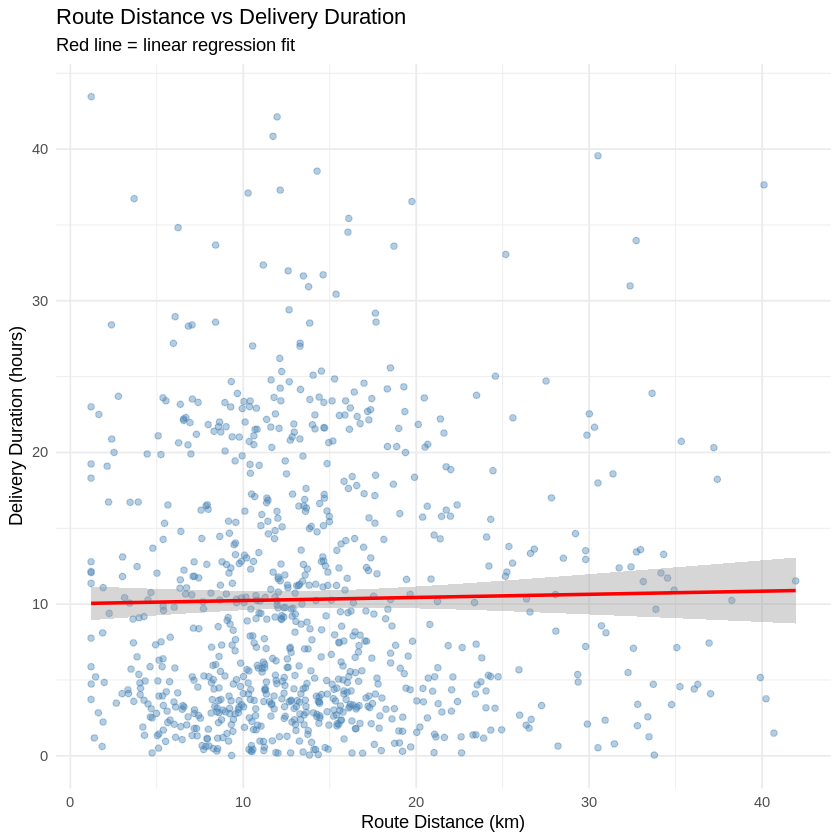

In [59]:
# --- CELL 20: ggplot — Regression scatter ---

ggplot(regression_data, aes(x = route_distance_km, y = duration_hours)) +
  geom_point(alpha = 0.4, colour = "steelblue") +
  geom_smooth(method = "lm", colour = "red", se = TRUE) +
  labs(title    = "Route Distance vs Delivery Duration",
       subtitle = "Red line = linear regression fit",
       x = "Route Distance (km)", y = "Delivery Duration (hours)") +
  theme_minimal()

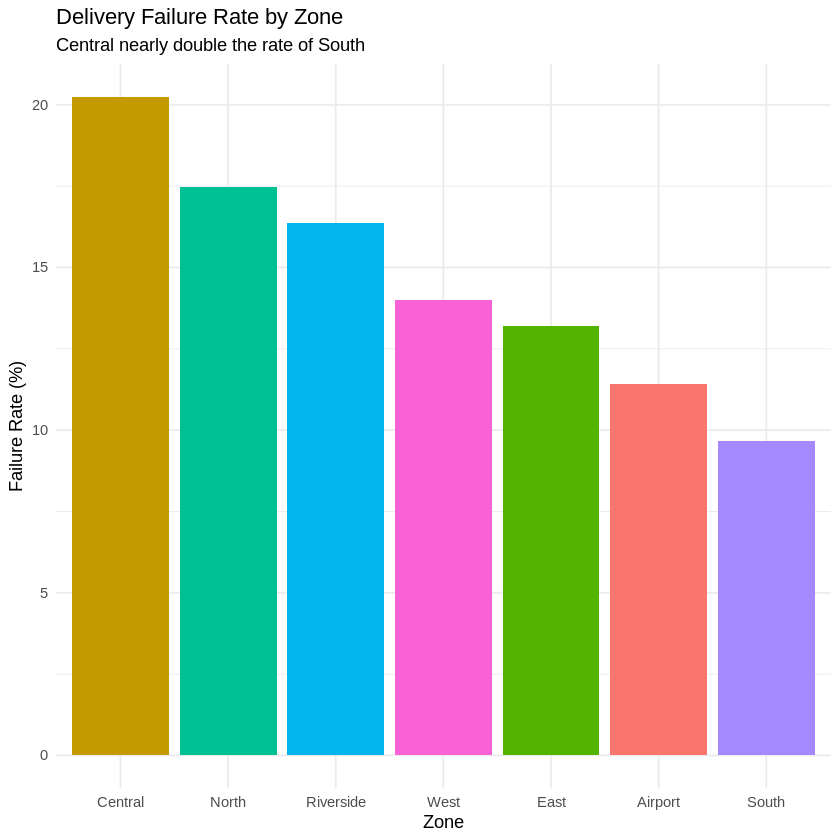

In [60]:
# --- CELL 21: ggplot — Failure rate by zone ---

ggplot(zone_performance,
       aes(x = reorder(pickup_zone, -failure_rate_pct),
           y = failure_rate_pct, fill = pickup_zone)) +
  geom_bar(stat = "identity") +
  labs(title    = "Delivery Failure Rate by Zone",
       subtitle = "Central nearly double the rate of South",
       x = "Zone", y = "Failure Rate (%)") +
  theme_minimal() + theme(legend.position = "none")

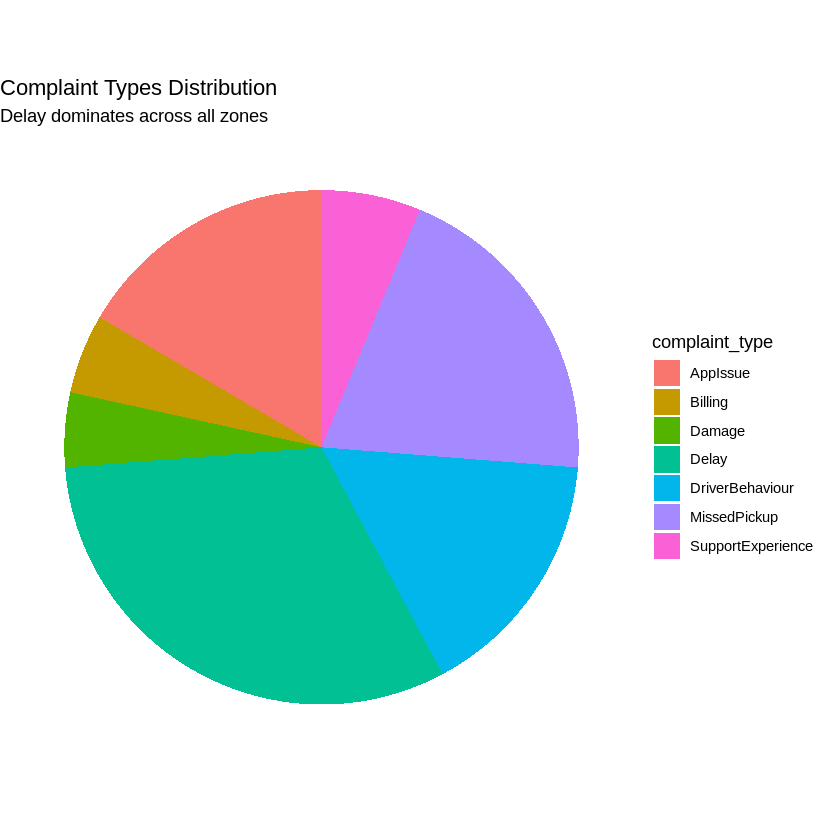

In [61]:
# --- CELL 22: ggplot — Complaint types pie chart ---

complaints %>%
  count(complaint_type) %>%
  ggplot(aes(x = "", y = n, fill = complaint_type)) +
  geom_bar(stat = "identity", width = 1) +
  coord_polar("y", start = 0) +
  labs(title    = "Complaint Types Distribution",
       subtitle = "Delay dominates across all zones") +
  theme_void()

`geom_smooth()` using formula = 'y ~ x'


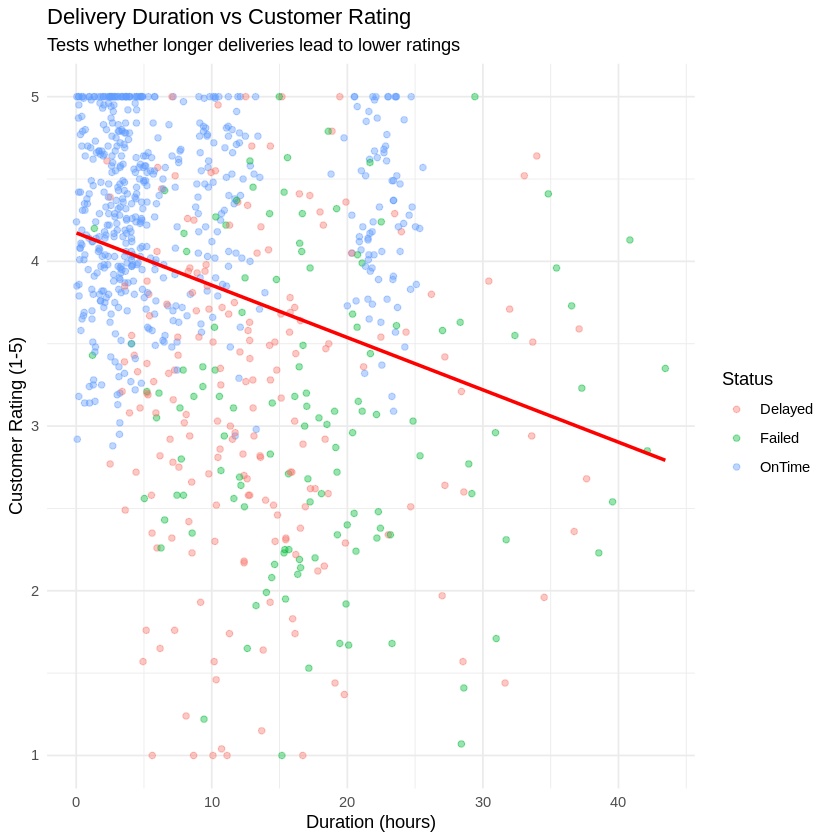

In [62]:
# --- CELL 23: ggplot — Duration vs customer rating ---

ggplot(valid_deliveries %>%
         filter(!is.na(customer_rating_post_delivery)),
       aes(x = duration_hours, y = customer_rating_post_delivery,
           colour = delivery_status)) +
  geom_point(alpha = 0.4) +
  geom_smooth(method = "lm", colour = "red", se = FALSE) +
  labs(title    = "Delivery Duration vs Customer Rating",
       subtitle = "Tests whether longer deliveries lead to lower ratings",
       x = "Duration (hours)", y = "Customer Rating (1-5)",
       colour = "Status") +
  theme_minimal()

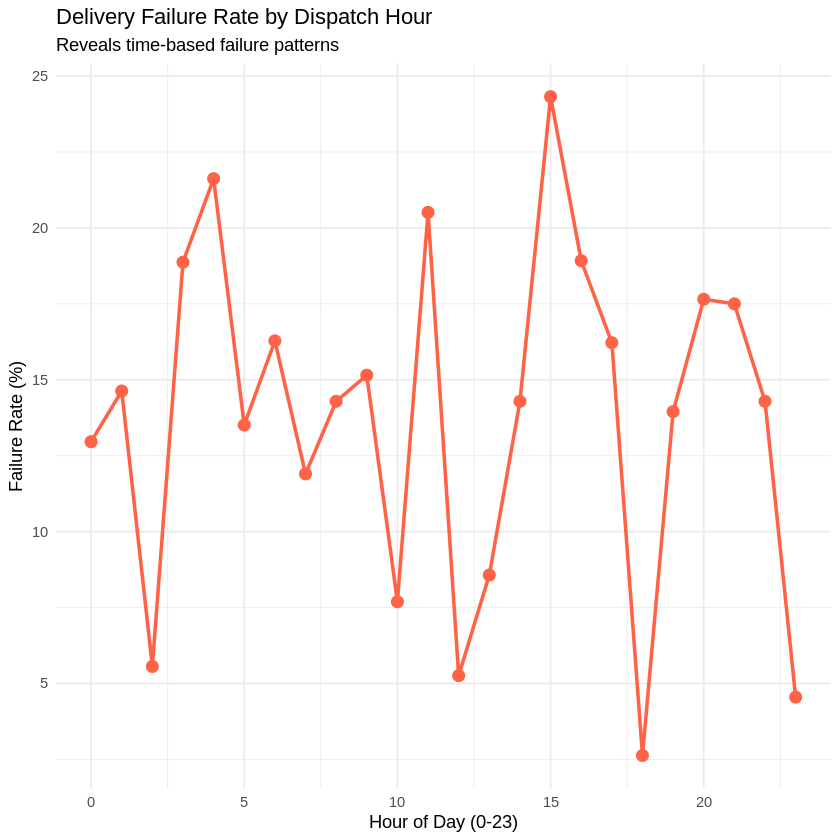

In [63]:
# --- CELL 24: ggplot — Failure rate by dispatch hour ---

hourly_failure <- deliveries %>%
  group_by(dispatch_hour) %>%
  summarise(total = n(),
            failed = sum(delivery_status == "Failed"),
            failure_pct = round(failed / total * 100, 2))

ggplot(hourly_failure, aes(x = dispatch_hour, y = failure_pct)) +
  geom_line(colour = "tomato", size = 1) +
  geom_point(colour = "tomato", size = 3) +
  labs(title    = "Delivery Failure Rate by Dispatch Hour",
       subtitle = "Reveals time-based failure patterns",
       x = "Hour of Day (0-23)", y = "Failure Rate (%)") +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'


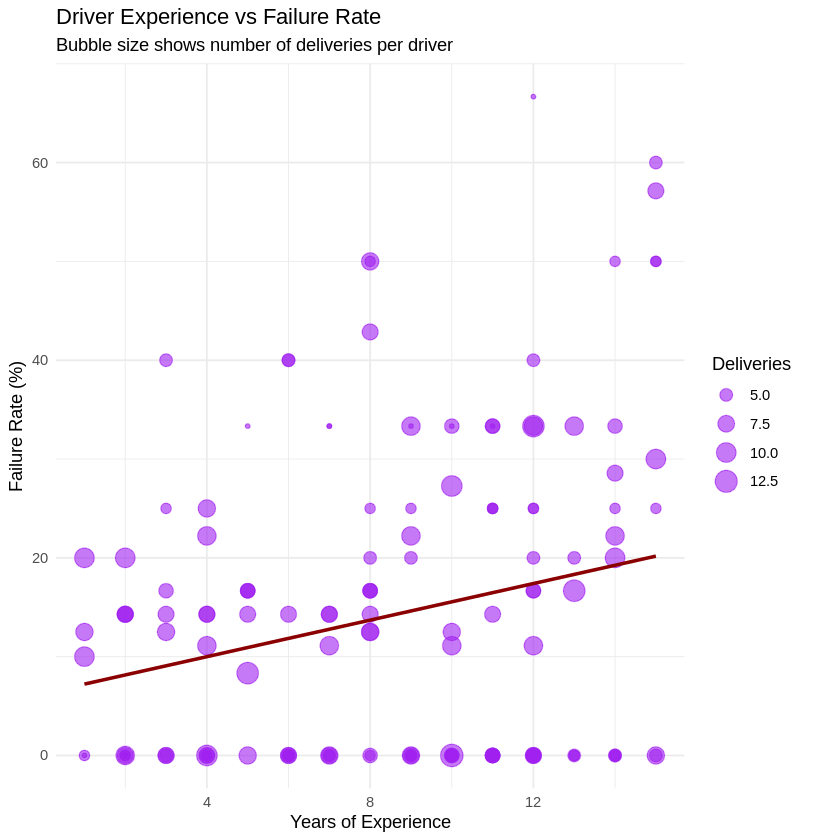

In [64]:
# --- CELL 25: ggplot — Driver experience vs failure rate ---

driver_exp <- deliveries %>%
  left_join(drivers, by = "driver_id") %>%
  group_by(driver_id) %>%
  summarise(years_experience = first(years_experience),
            failure_rate = round(mean(delivery_status == "Failed",
                                       na.rm = TRUE) * 100, 2),
            total_deliveries = n()) %>%
  filter(!is.na(years_experience), total_deliveries >= 3)

ggplot(driver_exp, aes(x = years_experience, y = failure_rate)) +
  geom_point(aes(size = total_deliveries),
             colour = "purple", alpha = 0.6) +
  geom_smooth(method = "lm", colour = "darkred", se = FALSE) +
  labs(title    = "Driver Experience vs Failure Rate",
       subtitle = "Bubble size shows number of deliveries per driver",
       x = "Years of Experience", y = "Failure Rate (%)",
       size = "Deliveries") +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'


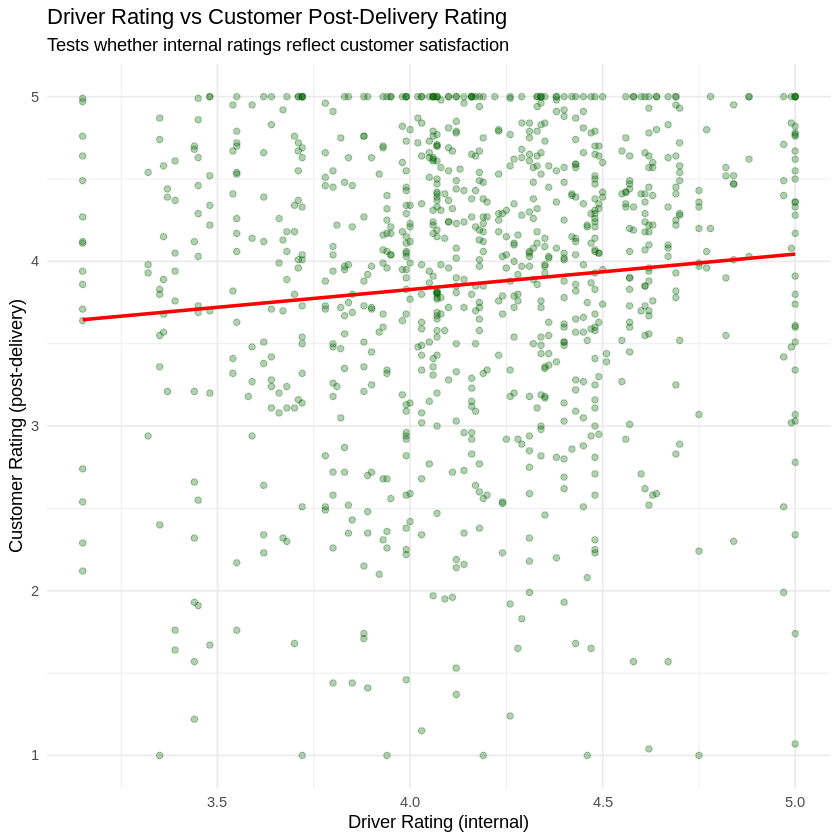

In [65]:
# --- CELL 26: ggplot — Driver rating vs customer rating ---

driver_satisfaction <- deliveries %>%
  left_join(drivers, by = "driver_id") %>%
  filter(!is.na(customer_rating_post_delivery), !is.na(driver_rating))

ggplot(driver_satisfaction,
       aes(x = driver_rating, y = customer_rating_post_delivery)) +
  geom_point(alpha = 0.3, colour = "darkgreen") +
  geom_smooth(method = "lm", colour = "red", se = FALSE) +
  labs(title    = "Driver Rating vs Customer Post-Delivery Rating",
       subtitle = "Tests whether internal ratings reflect customer satisfaction",
       x = "Driver Rating (internal)", y = "Customer Rating (post-delivery)") +
  theme_minimal()

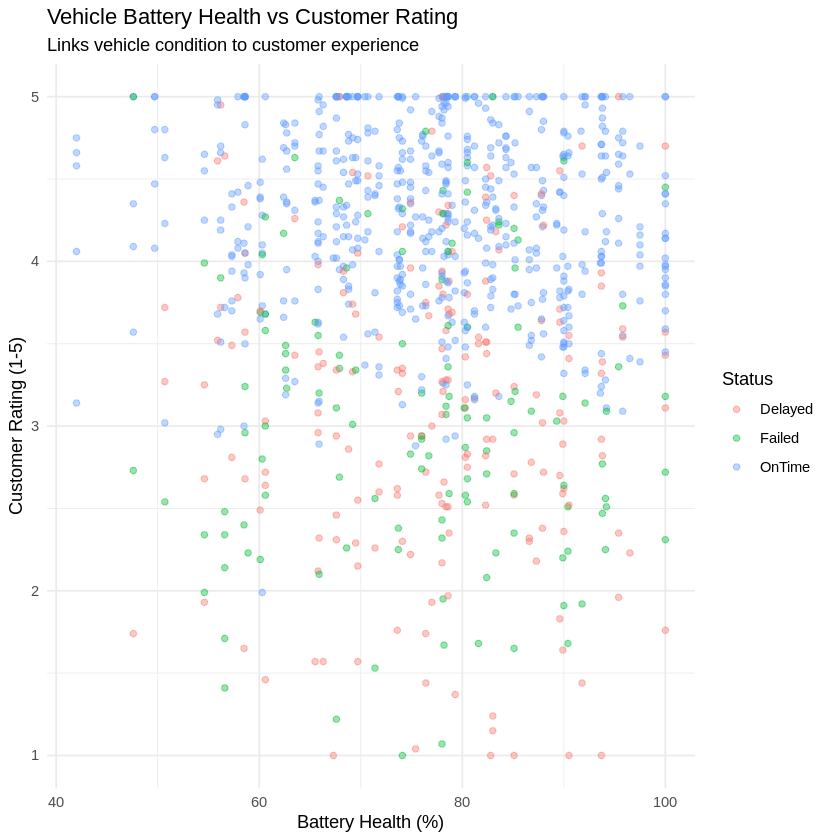

In [66]:
# --- CELL 27: ggplot — Battery health vs customer rating ---

battery_rating <- deliveries %>%
  left_join(vehicles, by = "vehicle_id") %>%
  filter(!is.na(battery_health_pct),
         !is.na(customer_rating_post_delivery))

ggplot(battery_rating,
       aes(x = battery_health_pct, y = customer_rating_post_delivery,
           colour = delivery_status)) +
  geom_point(alpha = 0.4) +
  labs(title    = "Vehicle Battery Health vs Customer Rating",
       subtitle = "Links vehicle condition to customer experience",
       x = "Battery Health (%)", y = "Customer Rating (1-5)",
       colour = "Status") +
  theme_minimal()

=== SERVICE TYPE PERFORMANCE (all 5 types) ===
# A tibble: 5 × 7
  service_type total_deliveries failure_rate_pct avg_margin avg_rating
  <chr>                   <int>            <dbl>      <dbl>      <dbl>
1 Business                  126             19.8       84.3       3.85
2 Medical                   108             14.8       73.8       3.84
3 Passenger                 262             14.5       84.8       3.85
4 Retail                    224             12.5       73.8       3.87
5 Parcel                    230             10.9       77.1       3.9 
# ℹ 2 more variables: avg_override <dbl>, sla_breach_rate <dbl>


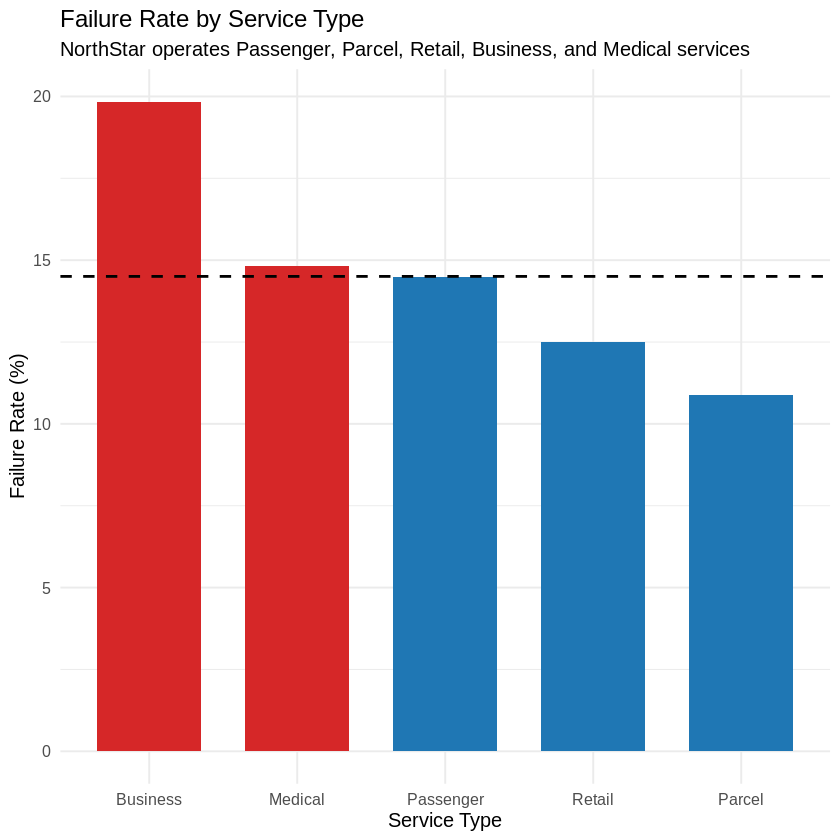

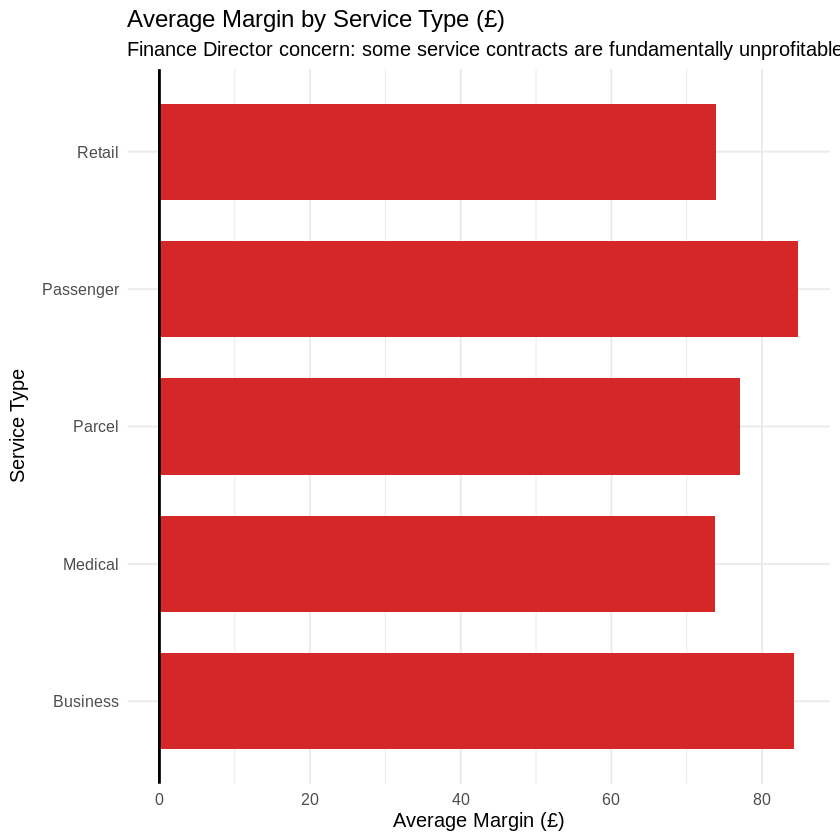

In [67]:
# --- CELL 28: Service type failure and profitability ---

service_perf_r <- deliveries %>%
  left_join(orders, by = "order_id") %>%
  filter(!is.na(service_type)) %>%
  group_by(service_type) %>%
  summarise(
    total_deliveries  = n(),
    failure_rate_pct  = round(mean(delivery_status == "Failed") * 100, 2),
    avg_margin        = round(mean(order_value - fuel_or_charge_cost, na.rm = TRUE), 2),
    avg_rating        = round(mean(customer_rating_post_delivery, na.rm = TRUE), 2),
    avg_override      = round(mean(manual_route_override_count, na.rm = TRUE), 3),
    sla_breach_rate   = round(mean(duration_hours > promised_window_hours,
                                   na.rm = TRUE) * 100, 2),
    .groups = "drop"
  ) %>%
  arrange(desc(failure_rate_pct))

cat("=== SERVICE TYPE PERFORMANCE (all 5 types) ===\n")
print(service_perf_r)

# ggplot — service type failure rates
ggplot(service_perf_r,
       aes(x = reorder(service_type, -failure_rate_pct),
           y = failure_rate_pct,
           fill = failure_rate_pct > mean(failure_rate_pct))) +
  geom_bar(stat = "identity", width = 0.7, show.legend = FALSE) +
  geom_hline(yintercept = mean(service_perf_r$failure_rate_pct),
             linetype = "dashed", colour = "black", linewidth = 0.8) +
  scale_fill_manual(values = c("#1f77b4", "#d62728")) +
  labs(
    title    = "Failure Rate by Service Type",
    subtitle = "NorthStar operates Passenger, Parcel, Retail, Business, and Medical services",
    x        = "Service Type",
    y        = "Failure Rate (%)"
  ) +
  theme_minimal(base_size = 12)

# ggplot — service type profitability
ggplot(service_perf_r,
       aes(x = service_type,
           y = avg_margin,
           fill = avg_margin > 0)) +
  geom_bar(stat = "identity", width = 0.7, show.legend = FALSE) +
  geom_hline(yintercept = 0, colour = "black", linewidth = 0.8) +
  scale_fill_manual(values = c("#d62728", "#2ca02c")) +
  coord_flip() +
  labs(
    title    = "Average Margin by Service Type (£)",
    subtitle = "Finance Director concern: some service contracts are fundamentally unprofitable",
    x        = "Service Type",
    y        = "Average Margin (£)"
  ) +
  theme_minimal(base_size = 12)

=== HUB TYPE PERFORMANCE ===
Case study concern: Charging hubs show heavy platform log usage
but low associated utilisation in asset monitoring reports.

# A tibble: 4 × 6
  hub_type  total_dispatches failure_rate_pct avg_capacity avg_overrides
  <chr>                <int>            <dbl>        <dbl>         <dbl>
1 Charging               128             20.3         63           1.11 
2 Control                115             20           88           0.948
3 Dispatch               473             12.3         75.2         0.937
4 Warehouse              234             10.7         70.1         0.97 
# ℹ 1 more variable: avg_fuel_cost <dbl>


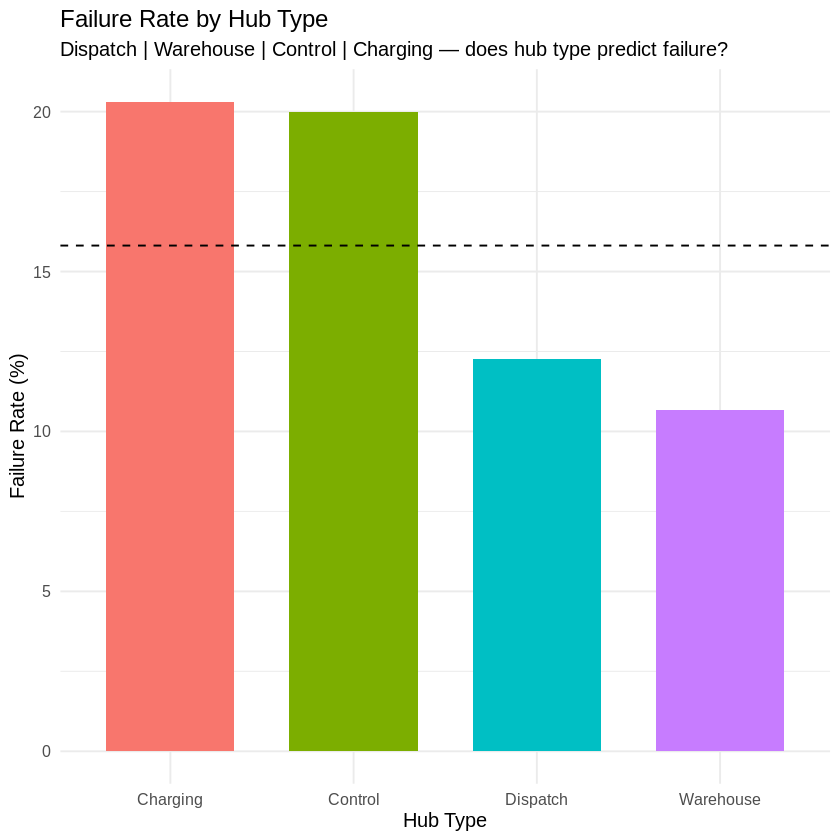

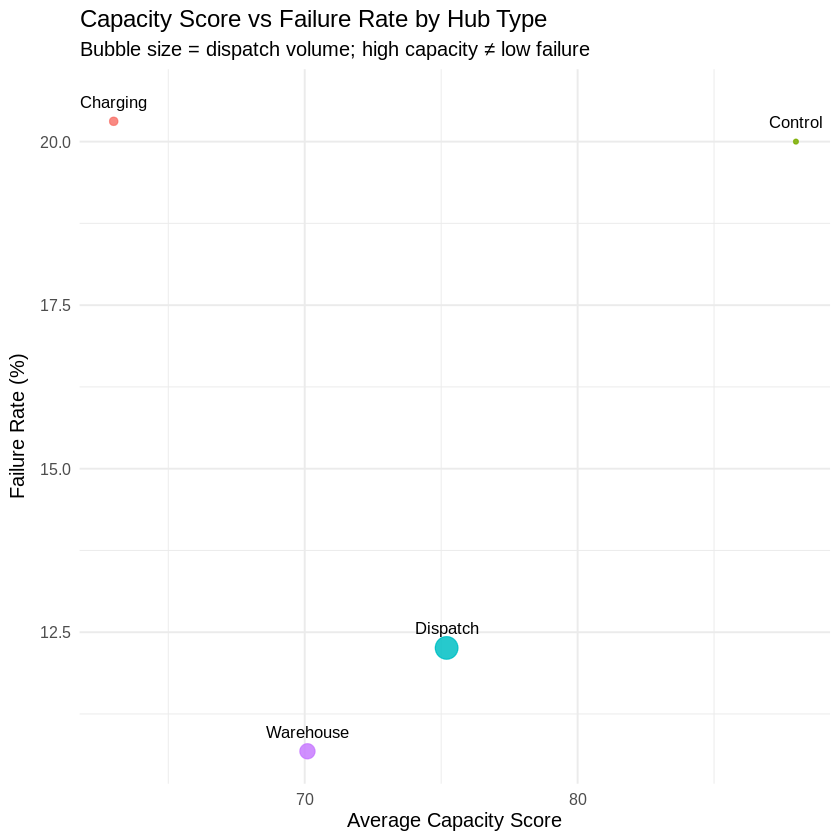

In [68]:
# --- CELL 29 : Hub type analysis ---

hub_type_r <- deliveries %>%
  left_join(hubs, by = "hub_id") %>%
  filter(!is.na(hub_type)) %>%
  group_by(hub_type) %>%
  summarise(
    total_dispatches  = n(),
    failure_rate_pct  = round(mean(delivery_status == "Failed") * 100, 2),
    avg_capacity      = round(mean(capacity_score, na.rm = TRUE), 1),
    avg_overrides     = round(mean(manual_route_override_count, na.rm = TRUE), 3),
    avg_fuel_cost     = round(mean(fuel_or_charge_cost, na.rm = TRUE), 2),
    .groups = "drop"
  ) %>%
  arrange(desc(failure_rate_pct))

cat("=== HUB TYPE PERFORMANCE ===\n")
cat("Case study concern: Charging hubs show heavy platform log usage\n")
cat("but low associated utilisation in asset monitoring reports.\n\n")
print(hub_type_r)

# ggplot — hub type failure rate
ggplot(hub_type_r,
       aes(x = reorder(hub_type, -failure_rate_pct),
           y = failure_rate_pct,
           fill = hub_type)) +
  geom_bar(stat = "identity", width = 0.7) +
  geom_hline(yintercept = mean(hub_type_r$failure_rate_pct),
             linetype = "dashed", colour = "black") +
  labs(
    title    = "Failure Rate by Hub Type",
    subtitle = "Dispatch | Warehouse | Control | Charging — does hub type predict failure?",
    x        = "Hub Type",
    y        = "Failure Rate (%)"
  ) +
  theme_minimal(base_size = 12) +
  theme(legend.position = "none")

# ggplot — capacity score vs failure rate scatter (hub type)
ggplot(hub_type_r,
       aes(x = avg_capacity,
           y = failure_rate_pct,
           colour = hub_type,
           size   = total_dispatches,
           label  = hub_type)) +
  geom_point(alpha = 0.85) +
  geom_text(nudge_y = 0.3, size = 3.5, colour = "black") +
  labs(
    title    = "Capacity Score vs Failure Rate by Hub Type",
    subtitle = "Bubble size = dispatch volume; high capacity ≠ low failure",
    x        = "Average Capacity Score",
    y        = "Failure Rate (%)"
  ) +
  theme_minimal(base_size = 12) +
  theme(legend.position = "none")

=== ZONE PROFITABILITY ===
# A tibble: 7 × 5
  pickup_zone total avg_margin loss_count loss_pct
  <chr>       <int>      <dbl>      <int>    <dbl>
1 Central       174       75.7          1     0.57
2 West          114       77.1          5     4.39
3 Riverside     119       77.9          3     2.52
4 North         135       78.2          3     2.22
5 South         139       79.9          3     2.16
6 East          156       80.9          5     3.21
7 Airport       113       84.6          3     2.65


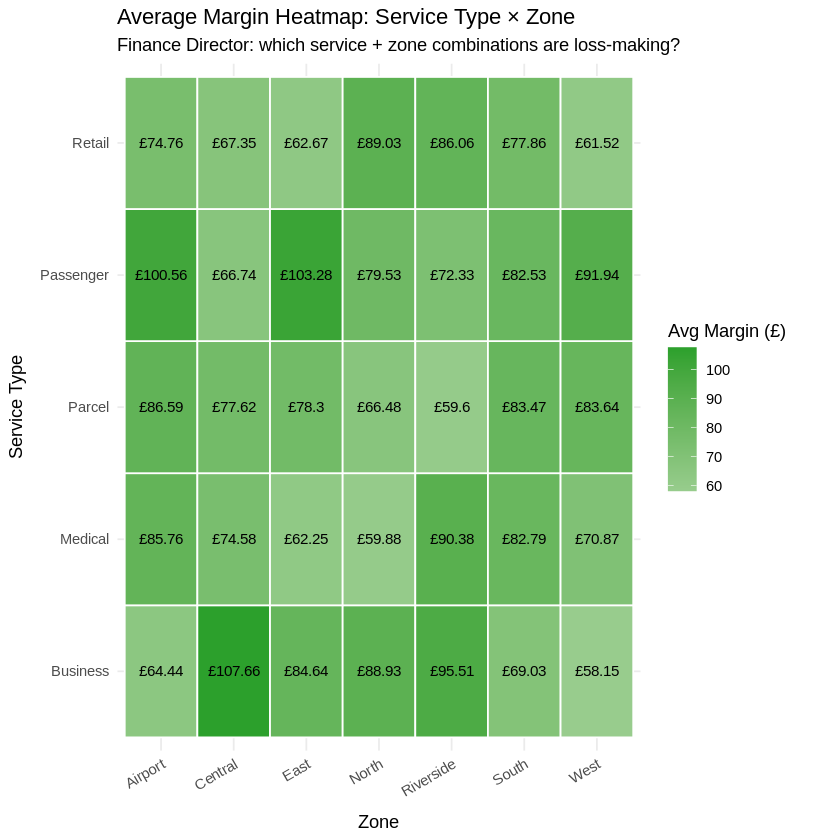

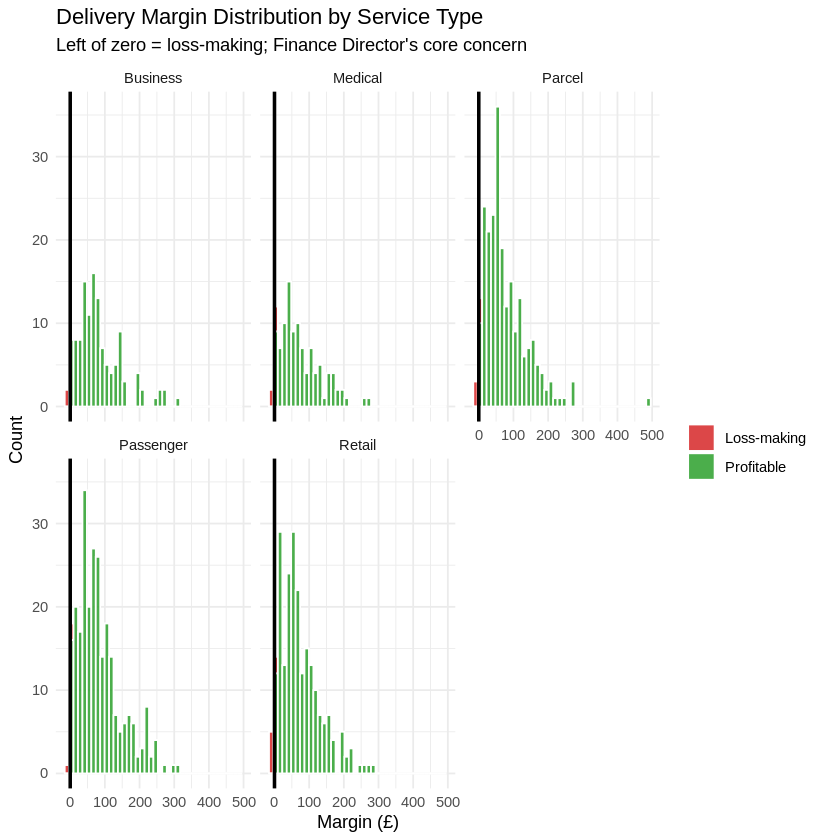

In [69]:
# --- CELL 30 : Profitability analysis ---

profitability_r <- deliveries %>%
  left_join(orders, by = "order_id") %>%
  filter(!is.na(order_value), !is.na(fuel_or_charge_cost)) %>%
  mutate(
    margin     = order_value - fuel_or_charge_cost,
    loss_flag  = if_else(margin < 0, "Loss-making", "Profitable")
  )

# Zone-level profitability
zone_profit <- profitability_r %>%
  group_by(pickup_zone) %>%
  summarise(
    total        = n(),
    avg_margin   = round(mean(margin), 2),
    loss_count   = sum(loss_flag == "Loss-making"),
    loss_pct     = round(mean(loss_flag == "Loss-making") * 100, 2),
    .groups = "drop"
  ) %>%
  arrange(avg_margin)

cat("=== ZONE PROFITABILITY ===\n")
print(zone_profit)

# Service type × zone profitability heatmap
service_zone_r <- profitability_r %>%
  group_by(service_type, pickup_zone) %>%
  summarise(avg_margin = round(mean(margin), 2), .groups = "drop")

ggplot(service_zone_r,
       aes(x = pickup_zone,
           y = service_type,
           fill = avg_margin)) +
  geom_tile(colour = "white", linewidth = 0.5) +
  geom_text(aes(label = paste0("£", avg_margin)), size = 3.2) +
  scale_fill_gradient2(low = "#d62728", mid = "white", high = "#2ca02c",
                       midpoint = 0, name = "Avg Margin (£)") +
  labs(
    title    = "Average Margin Heatmap: Service Type × Zone",
    subtitle = "Finance Director: which service + zone combinations are loss-making?",
    x        = "Zone",
    y        = "Service Type"
  ) +
  theme_minimal(base_size = 11) +
  theme(axis.text.x = element_text(angle = 30, hjust = 1))

# Distribution of margins
ggplot(profitability_r, aes(x = margin, fill = loss_flag)) +
  geom_histogram(bins = 40, alpha = 0.85, colour = "white") +
  geom_vline(xintercept = 0, colour = "black", linewidth = 1) +
  scale_fill_manual(values = c("Loss-making" = "#d62728",
                               "Profitable"  = "#2ca02c")) +
  facet_wrap(~service_type, ncol = 3) +
  labs(
    title    = "Delivery Margin Distribution by Service Type",
    subtitle = "Left of zero = loss-making; Finance Director's core concern",
    x        = "Margin (£)",
    y        = "Count",
    fill     = ""
  ) +
  theme_minimal(base_size = 11)

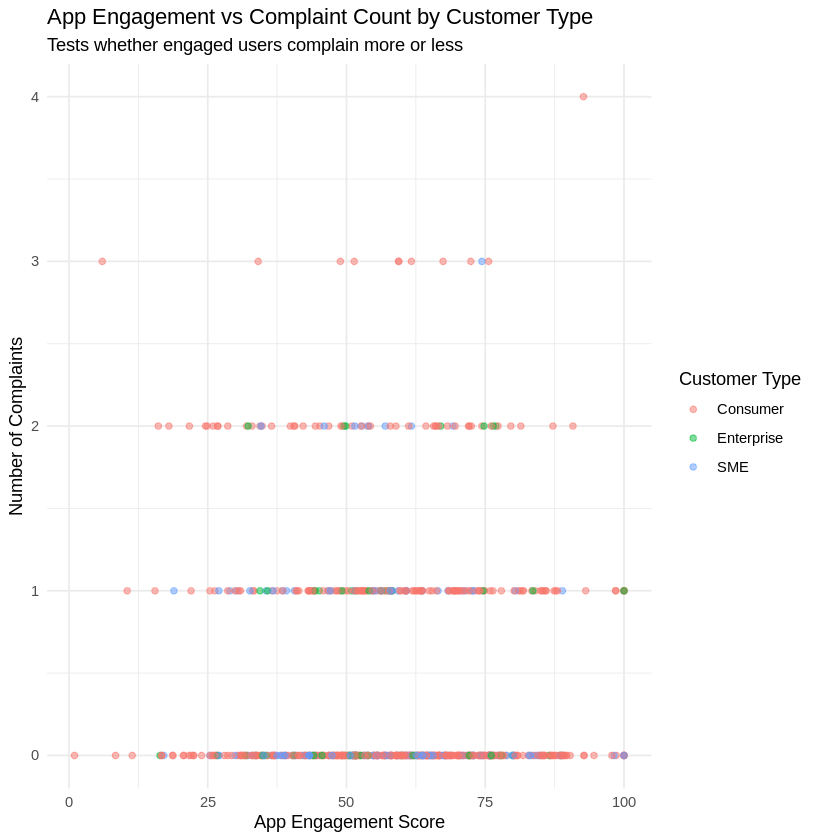

In [70]:
# --- CELL 31: ggplot — App engagement vs complaints ---

engagement_complaints <- customers %>%
  left_join(complaints, by = "customer_id") %>%
  group_by(customer_id) %>%
  summarise(app_engagement  = first(app_engagement_score),
            complaint_count = sum(!is.na(complaint_id)),
            customer_type   = first(customer_type))

ggplot(engagement_complaints,
       aes(x = app_engagement, y = complaint_count,
           colour = customer_type)) +
  geom_point(alpha = 0.5) +
  labs(title    = "App Engagement vs Complaint Count by Customer Type",
       subtitle = "Tests whether engaged users complain more or less",
       x = "App Engagement Score", y = "Number of Complaints",
       colour = "Customer Type") +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'


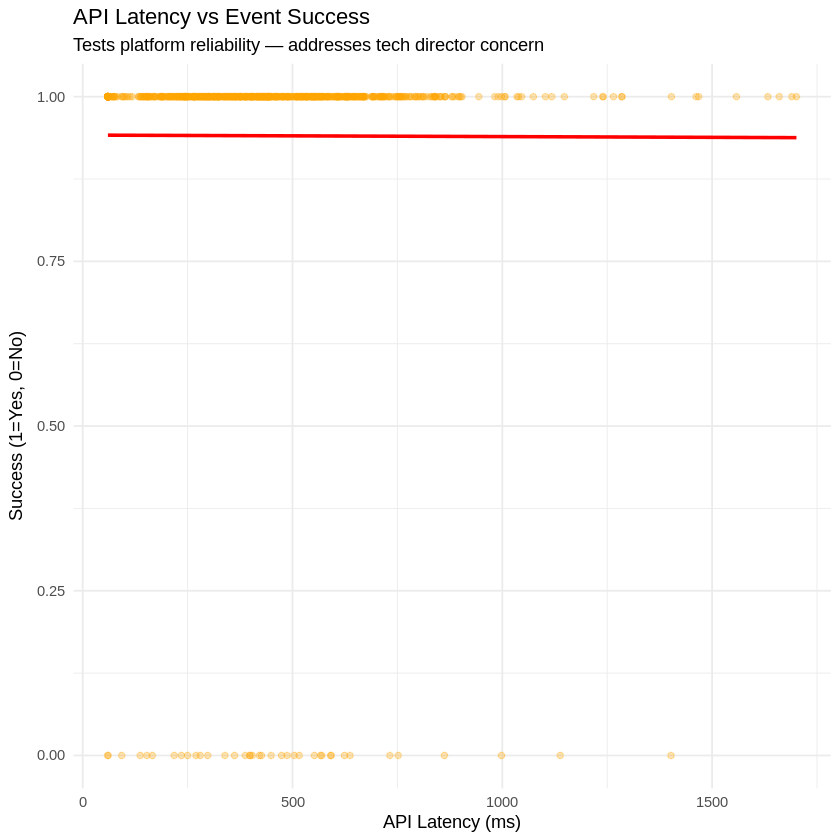

In [71]:
# --- CELL 32: ggplot — API latency vs success ---

ggplot(app_events, aes(x = api_latency_ms, y = success_flag)) +
  geom_point(alpha = 0.3, colour = "orange") +
  geom_smooth(method = "lm", colour = "red", se = FALSE) +
  labs(title    = "API Latency vs Event Success",
       subtitle = "Tests platform reliability — addresses tech director concern",
       x = "API Latency (ms)", y = "Success (1=Yes, 0=No)") +
  theme_minimal()